# Movie Success Prediction and Sentiment Study

## 1. Import Libraries and Load Data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

try:
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\varun\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [23]:
df = pd.read_csv('imdb_top_1000.csv')

print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Shape: (1000, 16)

First few rows:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## 2. Exploratory Data Analysis (EDA)

In [24]:
print("Dataset Information:")
print("="*50)
df.info()
print("\n" + "="*50)
print("\nBasic Statistics:")
print("="*50)
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


Basic Statisti

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [25]:
print("Missing Values:")
print("="*50)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

Missing Values:
             Missing_Count  Percentage
Gross                  169        16.9
Meta_score             157        15.7
Certificate            101        10.1


In [26]:
print("Cleaning data...\n")

df['Runtime_Minutes'] = df['Runtime'].str.replace(' min', '').astype(float)

df['Gross_Numeric'] = df['Gross'].str.replace(',', '').astype(float)

df['Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

print(f"Rows before cleaning: {len(df)}")
print(f"Missing Gross values: {df['Gross_Numeric'].isnull().sum()}")
print(f"Missing Meta_score values: {df['Meta_score'].isnull().sum()}")
print(f"Missing Overview values: {df['Overview'].isnull().sum()}")

df_clean = df.copy()

print(f"\nData cleaning completed!")

Cleaning data...

Rows before cleaning: 1000
Missing Gross values: 169
Missing Meta_score values: 157
Missing Overview values: 0

Data cleaning completed!


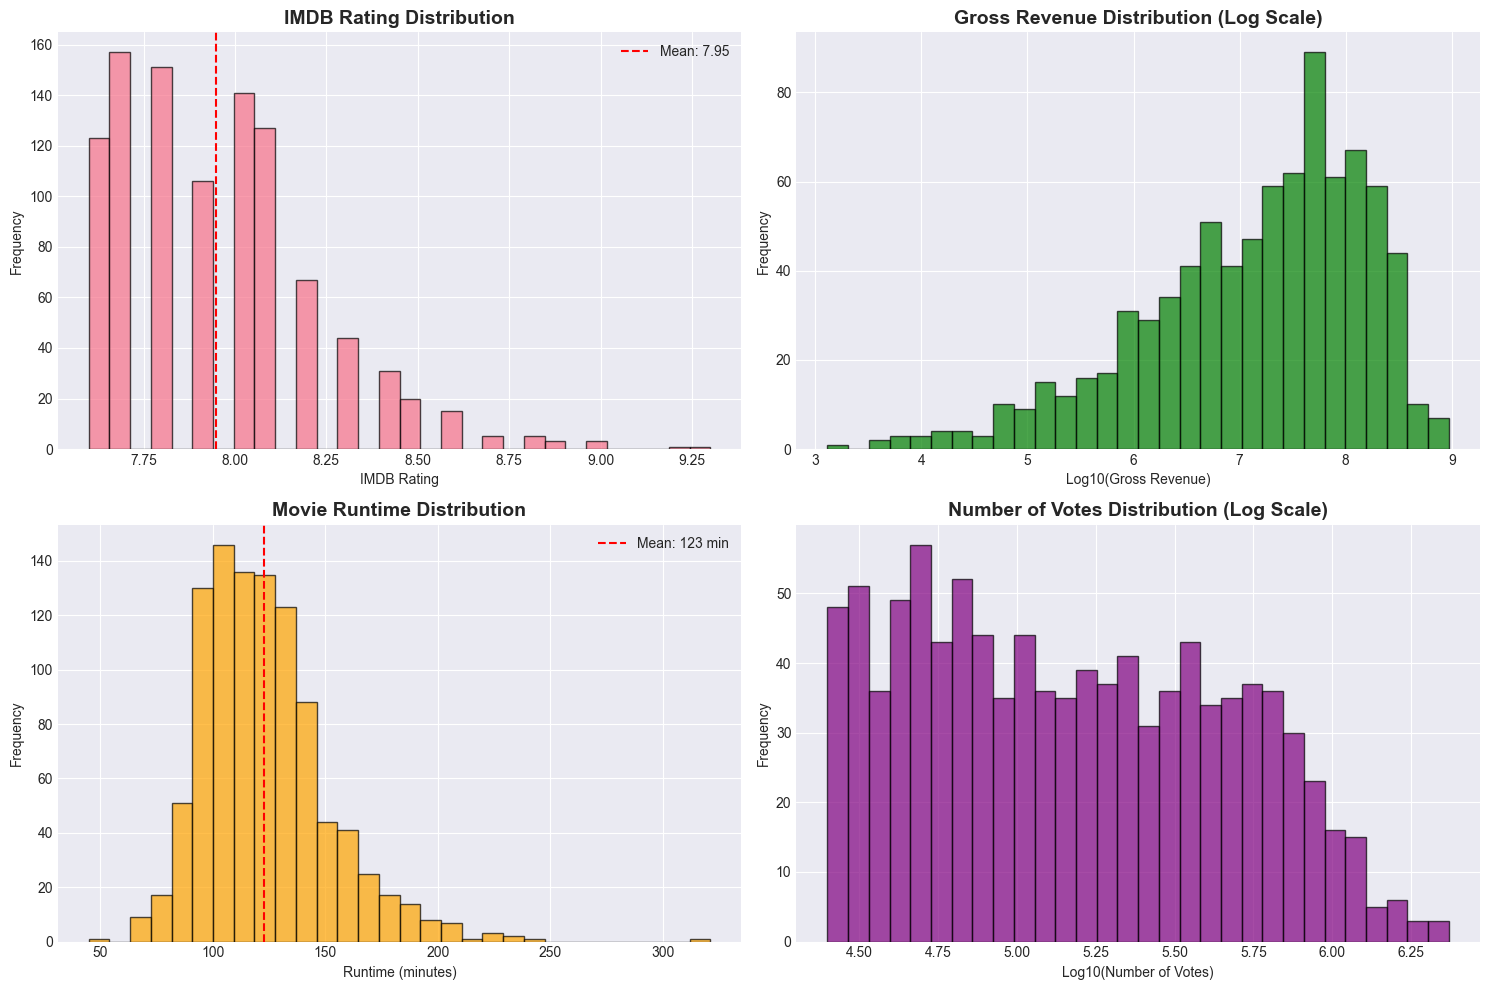

Distribution plots saved as 'distribution_analysis.png'


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df_clean['IMDB_Rating'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('IMDB Rating Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('IMDB Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_clean['IMDB_Rating'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['IMDB_Rating'].mean():.2f}")
axes[0, 0].legend()

gross_data = df_clean['Gross_Numeric'].dropna()
axes[0, 1].hist(np.log10(gross_data + 1), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Gross Revenue Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log10(Gross Revenue)')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df_clean['Runtime_Minutes'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Movie Runtime Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Runtime (minutes)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df_clean['Runtime_Minutes'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['Runtime_Minutes'].mean():.0f} min")
axes[1, 0].legend()

axes[1, 1].hist(np.log10(df_clean['No_of_Votes'] + 1), bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('Number of Votes Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Log10(Number of Votes)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution plots saved as 'distribution_analysis.png'")

## 3. Sentiment Analysis using VADER

In [28]:
sid = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    if pd.isna(text):
        return {'neg': 0, 'neu': 0, 'pos': 0, 'compound': 0}
    return sid.polarity_scores(str(text))

print("Performing sentiment analysis on movie overviews...\n")
df_clean['sentiment_scores'] = df_clean['Overview'].apply(get_sentiment_scores)

df_clean['sentiment_neg'] = df_clean['sentiment_scores'].apply(lambda x: x['neg'])
df_clean['sentiment_neu'] = df_clean['sentiment_scores'].apply(lambda x: x['neu'])
df_clean['sentiment_pos'] = df_clean['sentiment_scores'].apply(lambda x: x['pos'])
df_clean['sentiment_compound'] = df_clean['sentiment_scores'].apply(lambda x: x['compound'])

def categorize_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment_category'] = df_clean['sentiment_compound'].apply(categorize_sentiment)

print("Sentiment analysis completed!\n")
print("Sentiment Distribution:")
print("="*50)
print(df_clean['sentiment_category'].value_counts())
print("\nSentiment Statistics:")
print("="*50)
print(df_clean[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].describe())

Performing sentiment analysis on movie overviews...

Sentiment analysis completed!

Sentiment Distribution:
sentiment_category
Negative    573
Positive    303
Neutral     124
Name: count, dtype: int64

Sentiment Statistics:
       sentiment_neg  sentiment_neu  sentiment_pos  sentiment_compound
count    1000.000000    1000.000000    1000.000000         1000.000000
mean        0.142736       0.765256       0.091992           -0.161912
std         0.119224       0.137094       0.098592            0.523718
min         0.000000       0.355000       0.000000           -0.951700
25%         0.037750       0.672000       0.000000           -0.618875
50%         0.128000       0.772000       0.074500           -0.226300
75%         0.217250       0.857250       0.156250            0.255800
max         0.615000       1.000000       0.543000            0.954500


In [29]:
print("\nSample Movies with Sentiment Scores:")
print("="*100)
sample_cols = ['Series_Title', 'IMDB_Rating', 'Overview', 'sentiment_compound', 'sentiment_category']
df_clean[sample_cols].head(10)


Sample Movies with Sentiment Scores:


,Series_Title,IMDB_Rating,Overview,sentiment_compound,sentiment_category
0,The Shawshank Redemption,9.3,Two imprisoned men bond over a number of years...,-0.4019,Negative
1,The Godfather,9.2,An organized crime dynasty's aging patriarch t...,-0.6705,Negative
2,The Dark Knight,9.0,When the menace known as the Joker wreaks havo...,-0.8176,Negative
3,The Godfather: Part II,9.0,The early life and career of Vito Corleone in ...,-0.4767,Negative
4,12 Angry Men,9.0,A jury holdout attempts to prevent a miscarria...,0.5423,Positive
5,The Lord of the Rings: The Return of the King,8.9,Gandalf and Aragorn lead the World of Men agai...,-0.4019,Negative
6,Pulp Fiction,8.9,"The lives of two mob hitmen, a boxer, a gangst...",-0.6249,Negative
7,Schindler's List,8.9,"In German-occupied Poland during World War II,...",-0.5994,Negative
8,Inception,8.8,A thief who steals corporate secrets through t...,-0.7717,Negative
9,Fight Club,8.8,An insomniac office worker and a devil-may-car...,-0.3818,Negative


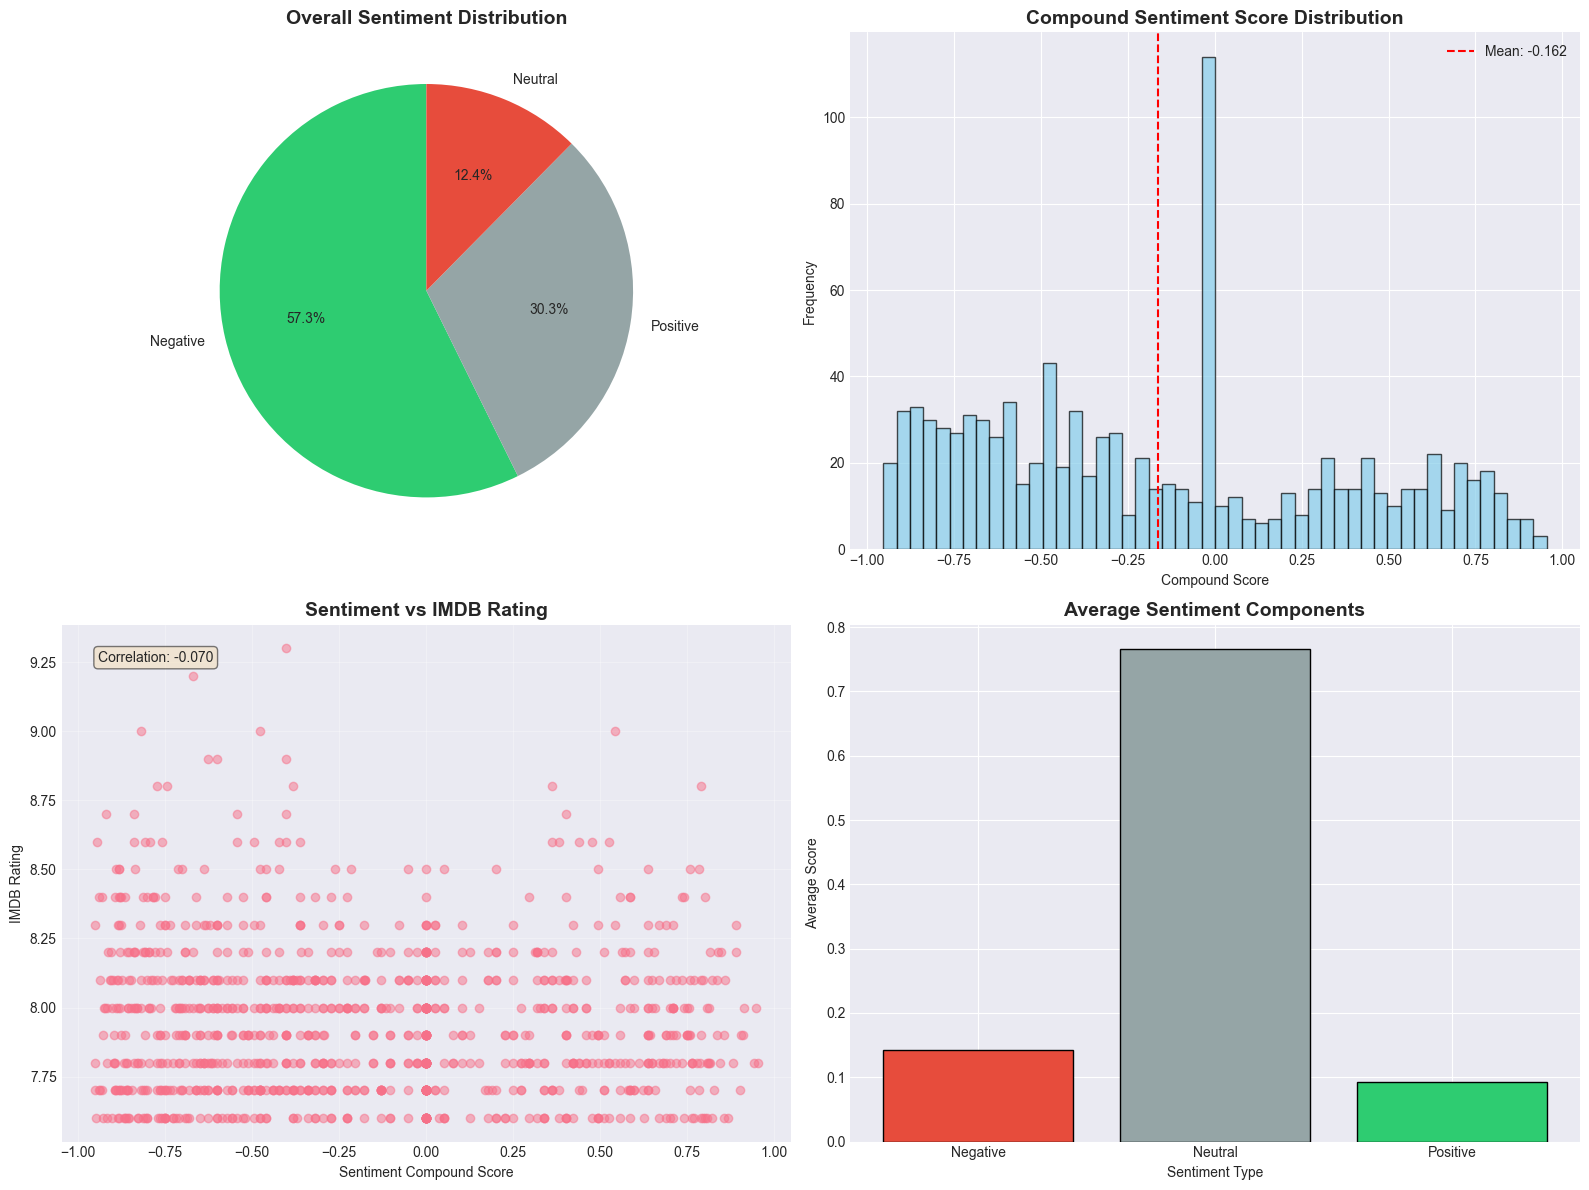

Sentiment visualization saved as 'sentiment_analysis_overview.png'


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sentiment_counts = df_clean['sentiment_category'].value_counts()
axes[0, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
               startangle=90, colors=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[0, 0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')

axes[0, 1].hist(df_clean['sentiment_compound'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].set_title('Compound Sentiment Score Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Compound Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_clean['sentiment_compound'].mean(), color='red', linestyle='--', 
                   label=f"Mean: {df_clean['sentiment_compound'].mean():.3f}")
axes[0, 1].legend()

axes[1, 0].scatter(df_clean['sentiment_compound'], df_clean['IMDB_Rating'], alpha=0.5)
axes[1, 0].set_title('Sentiment vs IMDB Rating', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sentiment Compound Score')
axes[1, 0].set_ylabel('IMDB Rating')
axes[1, 0].grid(True, alpha=0.3)

corr = df_clean[['sentiment_compound', 'IMDB_Rating']].corr().iloc[0, 1]
axes[1, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=axes[1, 0].transAxes, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), verticalalignment='top')

sentiment_components = df_clean[['sentiment_neg', 'sentiment_neu', 'sentiment_pos']].mean()
axes[1, 1].bar(sentiment_components.index, sentiment_components.values, 
               color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='black')
axes[1, 1].set_title('Average Sentiment Components', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sentiment Type')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].set_xticklabels(['Negative', 'Neutral', 'Positive'])

plt.tight_layout()
plt.savefig('sentiment_analysis_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sentiment visualization saved as 'sentiment_analysis_overview.png'")

## 4. Genre-wise Sentiment Analysis

In [31]:
df_clean['Primary_Genre'] = df_clean['Genre'].str.split(',').str[0].str.strip()

genre_sentiment = df_clean.groupby('Primary_Genre').agg({
    'sentiment_compound': ['mean', 'std', 'count'],
    'sentiment_pos': 'mean',
    'sentiment_neg': 'mean',
    'IMDB_Rating': 'mean',
    'Gross_Numeric': 'mean'
}).round(3)

genre_sentiment.columns = ['_'.join(col).strip() for col in genre_sentiment.columns.values]
genre_sentiment = genre_sentiment.sort_values('sentiment_compound_mean', ascending=False)

print("Genre-wise Sentiment Analysis:")
print("="*100)
print(genre_sentiment)

genre_sentiment_filtered = genre_sentiment[genre_sentiment['sentiment_compound_count'] >= 10]
print(f"\nGenres with at least 10 movies: {len(genre_sentiment_filtered)}")

Genre-wise Sentiment Analysis:
               sentiment_compound_mean  sentiment_compound_std  \
Primary_Genre                                                    
Family                           0.652                   0.178   
Fantasy                          0.019                   0.622   
Comedy                          -0.011                   0.504   
Film-Noir                       -0.022                   0.533   
Animation                       -0.072                   0.560   
Adventure                       -0.078                   0.527   
Biography                       -0.117                   0.488   
Drama                           -0.119                   0.531   
Western                         -0.191                   0.645   
Horror                          -0.261                   0.574   
Mystery                         -0.283                   0.530   
Action                          -0.329                   0.475   
Crime                           -0.384       

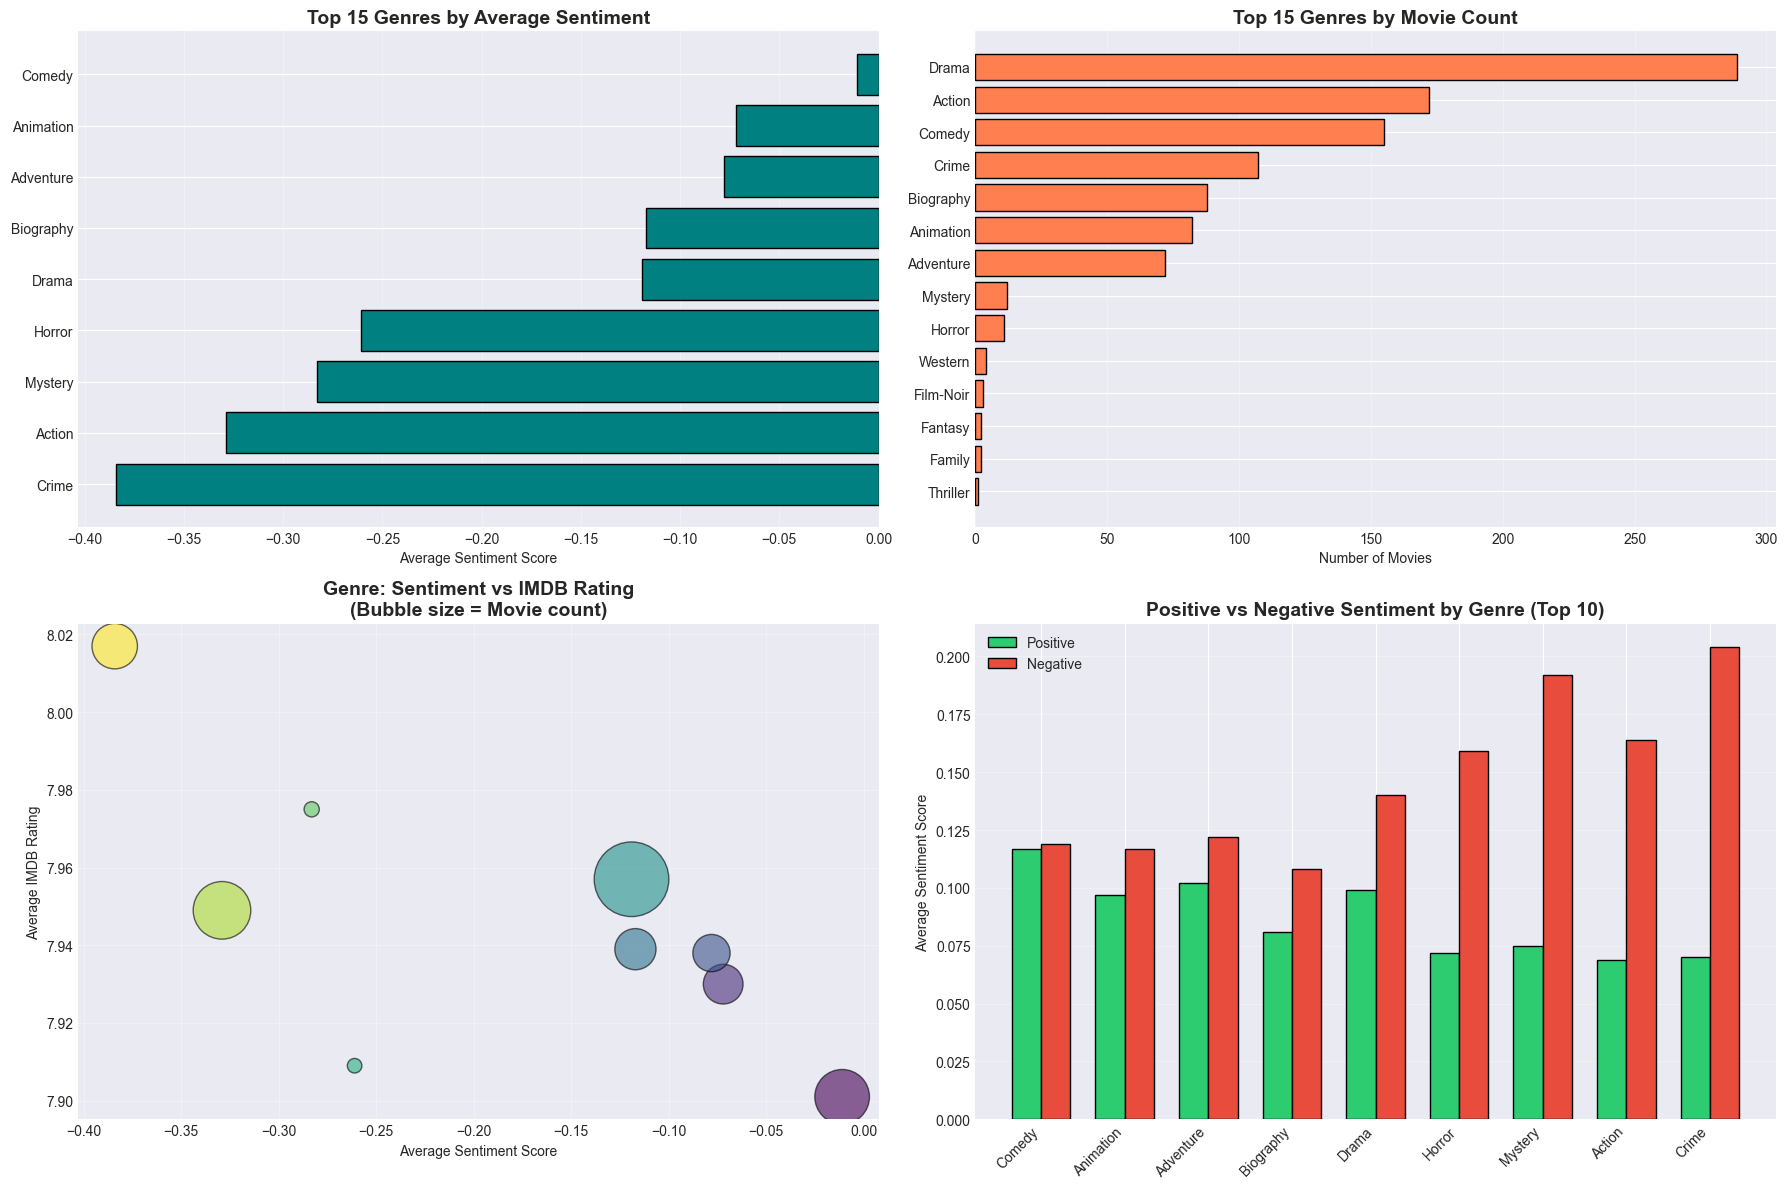

Genre sentiment visualization saved as 'genre_sentiment_analysis.png'


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_genres = genre_sentiment_filtered.head(15)
axes[0, 0].barh(range(len(top_genres)), top_genres['sentiment_compound_mean'].values, color='teal', edgecolor='black')
axes[0, 0].set_yticks(range(len(top_genres)))
axes[0, 0].set_yticklabels(top_genres.index)
axes[0, 0].set_xlabel('Average Sentiment Score')
axes[0, 0].set_title('Top 15 Genres by Average Sentiment', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

top_genre_counts = df_clean['Primary_Genre'].value_counts().head(15)
axes[0, 1].barh(range(len(top_genre_counts)), top_genre_counts.values, color='coral', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_genre_counts)))
axes[0, 1].set_yticklabels(top_genre_counts.index)
axes[0, 1].set_xlabel('Number of Movies')
axes[0, 1].set_title('Top 15 Genres by Movie Count', fontsize=14, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

axes[1, 0].scatter(genre_sentiment_filtered['sentiment_compound_mean'], 
                   genre_sentiment_filtered['IMDB_Rating_mean'],
                   s=genre_sentiment_filtered['sentiment_compound_count']*10,
                   alpha=0.6, c=range(len(genre_sentiment_filtered)), cmap='viridis', edgecolor='black')
axes[1, 0].set_xlabel('Average Sentiment Score')
axes[1, 0].set_ylabel('Average IMDB Rating')
axes[1, 0].set_title('Genre: Sentiment vs IMDB Rating\n(Bubble size = Movie count)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

genre_sent_components = genre_sentiment_filtered[['sentiment_pos_mean', 'sentiment_neg_mean']].head(10)
x = np.arange(len(genre_sent_components))
width = 0.35

axes[1, 1].bar(x - width/2, genre_sent_components['sentiment_pos_mean'], width, 
               label='Positive', color='#2ecc71', edgecolor='black')
axes[1, 1].bar(x + width/2, genre_sent_components['sentiment_neg_mean'], width,
               label='Negative', color='#e74c3c', edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(genre_sent_components.index, rotation=45, ha='right')
axes[1, 1].set_ylabel('Average Sentiment Score')
axes[1, 1].set_title('Positive vs Negative Sentiment by Genre (Top 10)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('genre_sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Genre sentiment visualization saved as 'genre_sentiment_analysis.png'")

## 5. Predictive Modeling - Box Office Success

In [33]:
print("Preparing data for box office prediction...\n")

df_gross = df_clean[df_clean['Gross_Numeric'].notna()].copy()
print(f"Movies with gross revenue data: {len(df_gross)}")

le_genre = LabelEncoder()
df_gross['Genre_Encoded'] = le_genre.fit_transform(df_gross['Primary_Genre'])

feature_cols = ['IMDB_Rating', 'Runtime_Minutes', 'No_of_Votes', 'Year', 
                'sentiment_compound', 'sentiment_pos', 'sentiment_neg',
                'Genre_Encoded']

df_gross['Meta_score_filled'] = df_gross['Meta_score'].fillna(df_gross['Meta_score'].median())
feature_cols.append('Meta_score_filled')

X_gross = df_gross[feature_cols].copy()
y_gross = np.log10(df_gross['Gross_Numeric'] + 1) 

X_gross = X_gross.fillna(X_gross.median())

print(f"Features: {feature_cols}")
print(f"Target: Gross Revenue (log-transformed)")
print(f"\nFeature correlations with Gross Revenue:")
print("="*50)
correlations = df_gross[feature_cols + ['Gross_Numeric']].corr()['Gross_Numeric'].sort_values(ascending=False)
print(correlations)

Preparing data for box office prediction...

Movies with gross revenue data: 831
Features: ['IMDB_Rating', 'Runtime_Minutes', 'No_of_Votes', 'Year', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'Genre_Encoded', 'Meta_score_filled']
Target: Gross Revenue (log-transformed)

Feature correlations with Gross Revenue:
Gross_Numeric         1.000000
No_of_Votes           0.574393
Year                  0.233250
Runtime_Minutes       0.139671
IMDB_Rating           0.095923
sentiment_pos         0.039685
sentiment_neg         0.030446
sentiment_compound   -0.031475
Meta_score_filled    -0.032592
Genre_Encoded        -0.324343
Name: Gross_Numeric, dtype: float64


In [34]:
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gross, y_gross, test_size=0.2, random_state=42
)

scaler_gross = StandardScaler()
X_train_g_scaled = scaler_gross.fit_transform(X_train_g)
X_test_g_scaled = scaler_gross.transform(X_test_g)

print(f"Training set size: {len(X_train_g)}")
print(f"Test set size: {len(X_test_g)}")

Training set size: 664
Test set size: 167


In [35]:
print("Training models for box office prediction...\n")

models_gross = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results_gross = {}

for name, model in models_gross.items():
    print(f"Training {name}...")
    model.fit(X_train_g_scaled, y_train_g)
    
    y_pred_train = model.predict(X_train_g_scaled)
    y_pred_test = model.predict(X_test_g_scaled)

    results_gross[name] = {
        'Train R2': r2_score(y_train_g, y_pred_train),
        'Test R2': r2_score(y_test_g, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_g, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_g, y_pred_test)),
        'Test MAE': mean_absolute_error(y_test_g, y_pred_test),
        'predictions': y_pred_test
    }

results_df_gross = pd.DataFrame(results_gross).T
print("\nBox Office Prediction Results:")
print("="*80)
print(results_df_gross[['Train R2', 'Test R2', 'Train RMSE', 'Test RMSE', 'Test MAE']])

Training models for box office prediction...

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...

Box Office Prediction Results:
                   Train R2   Test R2 Train RMSE Test RMSE  Test MAE
Linear Regression  0.448511  0.454139   0.777045  0.768015  0.594925
Ridge Regression   0.448504  0.454698    0.77705  0.767621  0.594522
Random Forest      0.922894  0.553856   0.290551   0.69433  0.536223
Gradient Boosting  0.963221  0.505423   0.200669  0.731047  0.546073


## 6. Predictive Modeling - IMDB Rating

In [36]:
print("Preparing data for IMDB rating prediction...\n")

df_rating = df_clean.copy()

feature_cols_rating = ['Runtime_Minutes', 'No_of_Votes', 'Year',
                       'sentiment_compound', 'sentiment_pos', 'sentiment_neg',
                       'Genre_Encoded']

le_genre_rating = LabelEncoder()
df_rating['Genre_Encoded'] = le_genre_rating.fit_transform(df_rating['Primary_Genre'])

df_rating['Meta_score_filled'] = df_rating['Meta_score'].fillna(df_rating['Meta_score'].median())
feature_cols_rating.append('Meta_score_filled')

X_rating = df_rating[feature_cols_rating].copy()
y_rating = df_rating['IMDB_Rating']

X_rating = X_rating.fillna(X_rating.median())

print(f"Total movies for rating prediction: {len(df_rating)}")
print(f"Features: {feature_cols_rating}")
print(f"\nFeature correlations with IMDB Rating:")
print("="*50)
correlations_rating = df_rating[feature_cols_rating + ['IMDB_Rating']].corr()['IMDB_Rating'].sort_values(ascending=False)
print(correlations_rating)

Preparing data for IMDB rating prediction...

Total movies for rating prediction: 1000
Features: ['Runtime_Minutes', 'No_of_Votes', 'Year', 'sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'Genre_Encoded', 'Meta_score_filled']

Feature correlations with IMDB Rating:
IMDB_Rating           1.000000
No_of_Votes           0.494979
Meta_score_filled     0.258650
Runtime_Minutes       0.243096
sentiment_neg         0.088108
Genre_Encoded         0.044005
sentiment_pos        -0.007504
sentiment_compound   -0.070356
Year                 -0.131053
Name: IMDB_Rating, dtype: float64


In [37]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rating, y_rating, test_size=0.2, random_state=42
)

scaler_rating = StandardScaler()
X_train_r_scaled = scaler_rating.fit_transform(X_train_r)
X_test_r_scaled = scaler_rating.transform(X_test_r)

print(f"Training set size: {len(X_train_r)}")
print(f"Test set size: {len(X_test_r)}")

Training set size: 800
Test set size: 200


In [38]:
print("Training models for IMDB rating prediction...\n")

models_rating = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

results_rating = {}

for name, model in models_rating.items():
    print(f"Training {name}...")
    model.fit(X_train_r_scaled, y_train_r)
    
    y_pred_train = model.predict(X_train_r_scaled)
    y_pred_test = model.predict(X_test_r_scaled)

    results_rating[name] = {
        'Train R2': r2_score(y_train_r, y_pred_train),
        'Test R2': r2_score(y_test_r, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train_r, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test_r, y_pred_test)),
        'Test MAE': mean_absolute_error(y_test_r, y_pred_test),
        'predictions': y_pred_test
    }

results_df_rating = pd.DataFrame(results_rating).T
print("\nIMDB Rating Prediction Results:")
print("="*80)
print(results_df_rating[['Train R2', 'Test R2', 'Train RMSE', 'Test RMSE', 'Test MAE']])

Training models for IMDB rating prediction...

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...

IMDB Rating Prediction Results:
                   Train R2   Test R2 Train RMSE Test RMSE  Test MAE
Linear Regression  0.424026  0.254306   0.212897  0.218637  0.176266
Ridge Regression   0.424025  0.254664   0.212897  0.218584  0.176238
Random Forest      0.846284  0.313837   0.109984  0.209728  0.162455
Gradient Boosting  0.914068  0.267242   0.082233  0.216732  0.168014


## 7. Model Evaluation and Visualization

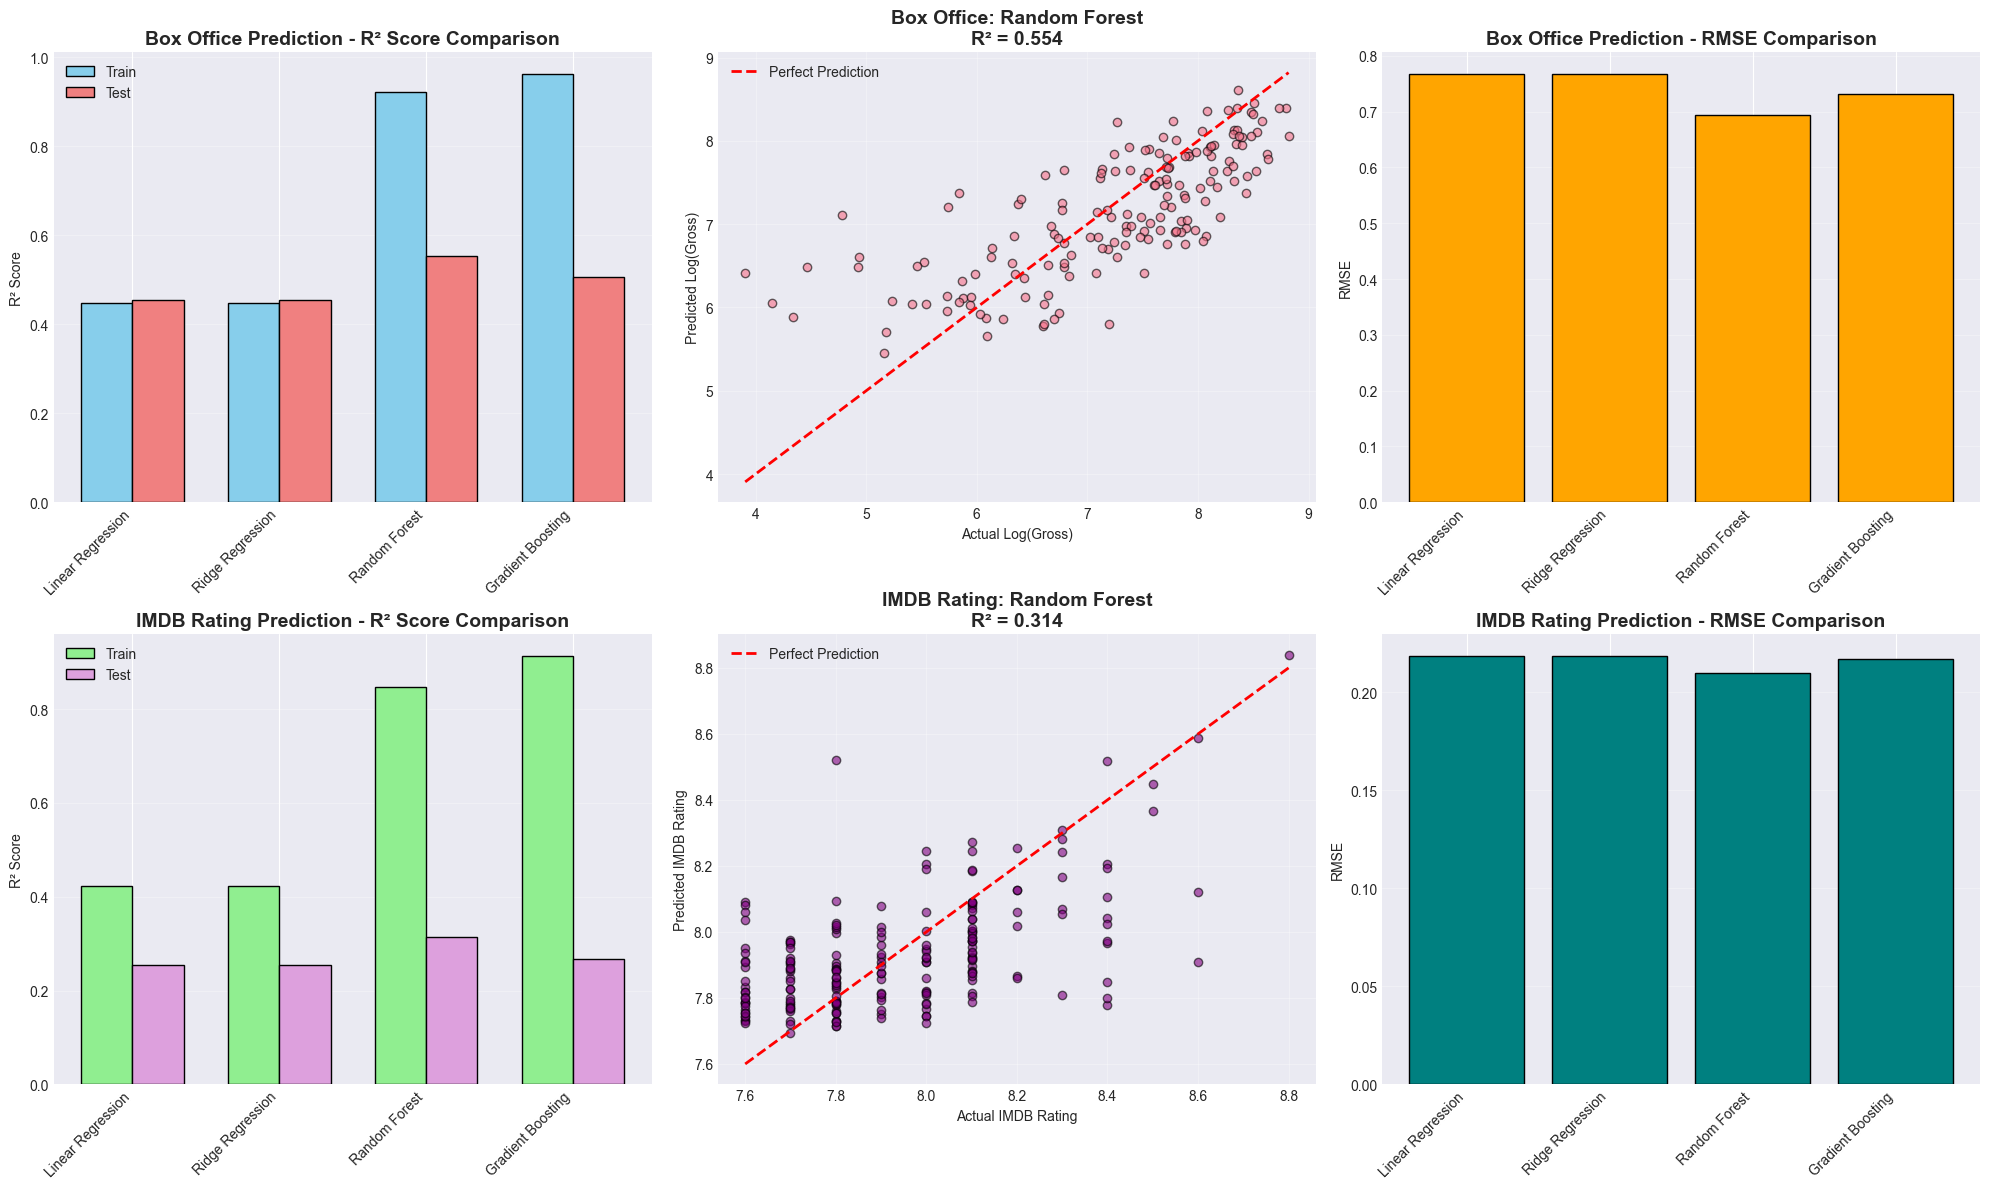

Model performance visualization saved as 'model_performance_comparison.png'


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

model_names = list(results_gross.keys())
train_r2_gross = [results_gross[m]['Train R2'] for m in model_names]
test_r2_gross = [results_gross[m]['Test R2'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[0, 0].bar(x - width/2, train_r2_gross, width, label='Train', color='skyblue', edgecolor='black')
axes[0, 0].bar(x + width/2, test_r2_gross, width, label='Test', color='lightcoral', edgecolor='black')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Box Office Prediction - R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

best_model_gross = max(results_gross.keys(), key=lambda k: results_gross[k]['Test R2'])
y_pred_best_gross = results_gross[best_model_gross]['predictions']

axes[0, 1].scatter(y_test_g, y_pred_best_gross, alpha=0.6, edgecolor='black')
axes[0, 1].plot([y_test_g.min(), y_test_g.max()], [y_test_g.min(), y_test_g.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Log(Gross)')
axes[0, 1].set_ylabel('Predicted Log(Gross)')
axes[0, 1].set_title(f'Box Office: {best_model_gross}\nR² = {results_gross[best_model_gross]["Test R2"]:.3f}', 
                     fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

test_rmse_gross = [results_gross[m]['Test RMSE'] for m in model_names]
axes[0, 2].bar(model_names, test_rmse_gross, color='orange', edgecolor='black')
axes[0, 2].set_xticklabels(model_names, rotation=45, ha='right')
axes[0, 2].set_ylabel('RMSE')
axes[0, 2].set_title('Box Office Prediction - RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 2].grid(axis='y', alpha=0.3)

model_names_r = list(results_rating.keys())
train_r2_rating = [results_rating[m]['Train R2'] for m in model_names_r]
test_r2_rating = [results_rating[m]['Test R2'] for m in model_names_r]

axes[1, 0].bar(x - width/2, train_r2_rating, width, label='Train', color='lightgreen', edgecolor='black')
axes[1, 0].bar(x + width/2, test_r2_rating, width, label='Test', color='plum', edgecolor='black')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(model_names_r, rotation=45, ha='right')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('IMDB Rating Prediction - R² Score Comparison', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

best_model_rating = max(results_rating.keys(), key=lambda k: results_rating[k]['Test R2'])
y_pred_best_rating = results_rating[best_model_rating]['predictions']

axes[1, 1].scatter(y_test_r, y_pred_best_rating, alpha=0.6, edgecolor='black', color='purple')
axes[1, 1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 
                'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual IMDB Rating')
axes[1, 1].set_ylabel('Predicted IMDB Rating')
axes[1, 1].set_title(f'IMDB Rating: {best_model_rating}\nR² = {results_rating[best_model_rating]["Test R2"]:.3f}', 
                     fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

test_rmse_rating = [results_rating[m]['Test RMSE'] for m in model_names_r]
axes[1, 2].bar(model_names_r, test_rmse_rating, color='teal', edgecolor='black')
axes[1, 2].set_xticklabels(model_names_r, rotation=45, ha='right')
axes[1, 2].set_ylabel('RMSE')
axes[1, 2].set_title('IMDB Rating Prediction - RMSE Comparison', fontsize=14, fontweight='bold')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model performance visualization saved as 'model_performance_comparison.png'")

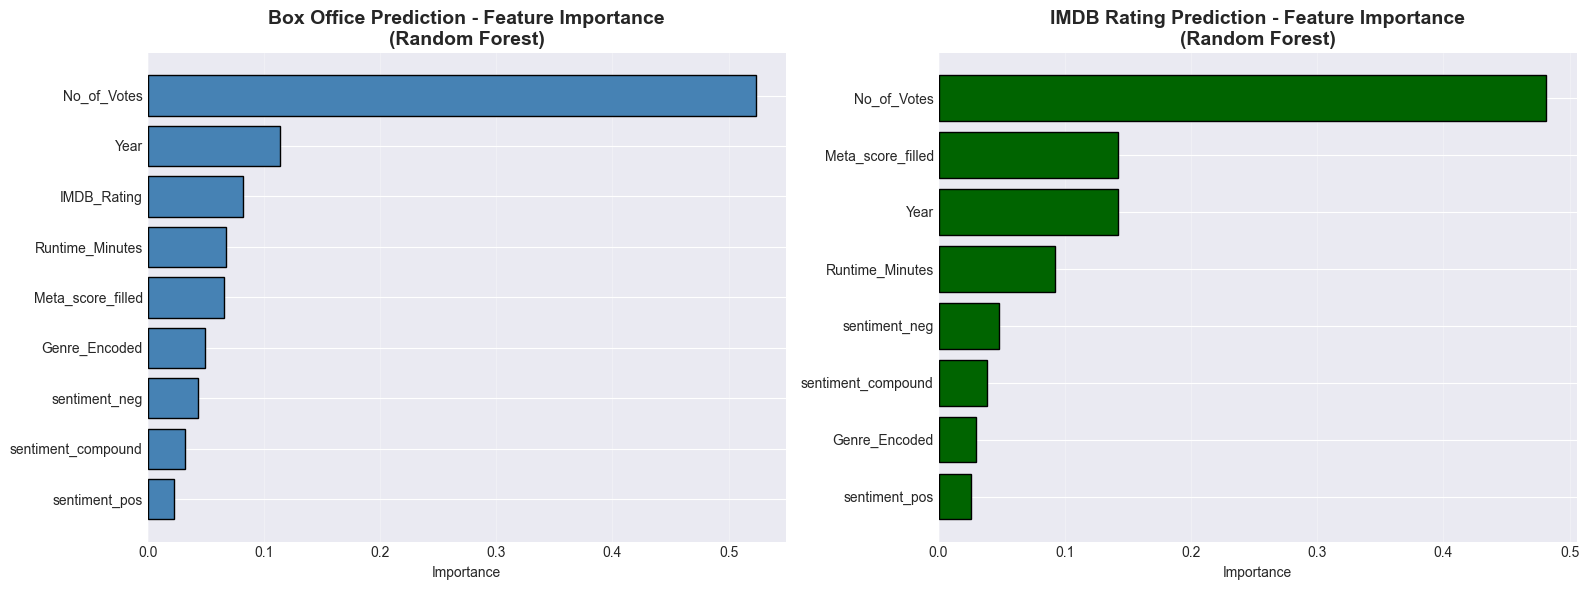

Feature importance visualization saved as 'feature_importance.png'


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_gross = models_gross['Random Forest']
feature_importance_gross = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_gross.feature_importances_
}).sort_values('Importance', ascending=False)

axes[0].barh(range(len(feature_importance_gross)), feature_importance_gross['Importance'].values, 
             color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(feature_importance_gross)))
axes[0].set_yticklabels(feature_importance_gross['Feature'].values)
axes[0].set_xlabel('Importance')
axes[0].set_title('Box Office Prediction - Feature Importance\n(Random Forest)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

rf_rating = models_rating['Random Forest']
feature_importance_rating = pd.DataFrame({
    'Feature': feature_cols_rating,
    'Importance': rf_rating.feature_importances_
}).sort_values('Importance', ascending=False)

axes[1].barh(range(len(feature_importance_rating)), feature_importance_rating['Importance'].values,
             color='darkgreen', edgecolor='black')
axes[1].set_yticks(range(len(feature_importance_rating)))
axes[1].set_yticklabels(feature_importance_rating['Feature'].values)
axes[1].set_xlabel('Importance')
axes[1].set_title('IMDB Rating Prediction - Feature Importance\n(Random Forest)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature importance visualization saved as 'feature_importance.png'")

## 8. Model Summary and Key Insights

In [41]:
print("="*100)
print(" " * 30 + "PREDICTIVE MODEL SUMMARY")
print("="*100)

print("\n BOX OFFICE PREDICTION MODEL")
print("-" * 100)
print(f"Dataset Size: {len(df_gross)} movies with gross revenue data")
print(f"\nBest Model: {best_model_gross}")
print(f"  • Test R² Score: {results_gross[best_model_gross]['Test R2']:.4f}")
print(f"  • Test RMSE: {results_gross[best_model_gross]['Test RMSE']:.4f}")
print(f"  • Test MAE: {results_gross[best_model_gross]['Test MAE']:.4f}")
print(f"\nTop 3 Important Features (Random Forest):")
for idx, row in feature_importance_gross.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n\n IMDB RATING PREDICTION MODEL")
print("-" * 100)
print(f"Dataset Size: {len(df_rating)} movies")
print(f"\nBest Model: {best_model_rating}")
print(f"  • Test R² Score: {results_rating[best_model_rating]['Test R2']:.4f}")
print(f"  • Test RMSE: {results_rating[best_model_rating]['Test RMSE']:.4f}")
print(f"  • Test MAE: {results_rating[best_model_rating]['Test MAE']:.4f}")
print(f"\nTop 3 Important Features (Random Forest):")
for idx, row in feature_importance_rating.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print("\n\n SENTIMENT ANALYSIS SUMMARY")
print("-" * 100)
print(f"Total Movies Analyzed: {len(df_clean)}")
print(f"\nSentiment Distribution:")
sentiment_dist = df_clean['sentiment_category'].value_counts()
for cat, count in sentiment_dist.items():
    pct = (count / len(df_clean)) * 100
    print(f"  • {cat}: {count} ({pct:.1f}%)")
print(f"\nAverage Sentiment Compound Score: {df_clean['sentiment_compound'].mean():.4f}")
print(f"Sentiment-Rating Correlation: {df_clean[['sentiment_compound', 'IMDB_Rating']].corr().iloc[0, 1]:.4f}")

print("\n\n GENRE INSIGHTS")
print("-" * 100)
print(f"\nTop 5 Genres by Average Sentiment:")
for idx, (genre, row) in enumerate(genre_sentiment_filtered.head(5).iterrows(), 1):
    print(f"  {idx}. {genre}: {row['sentiment_compound_mean']:.4f} ({int(row['sentiment_compound_count'])} movies)")

print(f"\n\nTop 5 Most Common Genres:")
top_genres_list = df_clean['Primary_Genre'].value_counts().head(5)
for idx, (genre, count) in enumerate(top_genres_list.items(), 1):
    avg_rating = df_clean[df_clean['Primary_Genre'] == genre]['IMDB_Rating'].mean()
    print(f"  {idx}. {genre}: {count} movies (Avg Rating: {avg_rating:.2f})")

print("\n" + "="*100)
print(" " * 35 + "ANALYSIS COMPLETE")
print("="*100)

                              PREDICTIVE MODEL SUMMARY

 BOX OFFICE PREDICTION MODEL
----------------------------------------------------------------------------------------------------
Dataset Size: 831 movies with gross revenue data

Best Model: Random Forest
  • Test R² Score: 0.5539
  • Test RMSE: 0.6943
  • Test MAE: 0.5362

Top 3 Important Features (Random Forest):
  3. No_of_Votes: 0.5232
  4. Year: 0.1138
  1. IMDB_Rating: 0.0822


 IMDB RATING PREDICTION MODEL
----------------------------------------------------------------------------------------------------
Dataset Size: 1000 movies

Best Model: Random Forest
  • Test R² Score: 0.3138
  • Test RMSE: 0.2097
  • Test MAE: 0.1625

Top 3 Important Features (Random Forest):
  2. No_of_Votes: 0.4818
  8. Meta_score_filled: 0.1423
  3. Year: 0.1420


 SENTIMENT ANALYSIS SUMMARY
----------------------------------------------------------------------------------------------------
Total Movies Analyzed: 1000

Sentiment Distribution:
  